### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

pd.set_option('display.max_columns',None)
plt.style.use('seaborn-v0_8')

### Load Data

In [2]:
path = '../../data/groceries/feature_frame.csv'
df_raw = pd.read_csv(path)

In [3]:
df_raw.head(5)

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,discount_pct,vendor,global_popularity,count_adults,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.000000,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.000000,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.000000,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.038462,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.038462,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

### Data Preprocessing

- Requirement: Filter the dataset for orders with at least 5 items.

In [4]:
def convert_to_datetime(df, columns =['created_at', 'order_date'])->pd.DataFrame:
    for col in columns:
        df[col] = pd.to_datetime(df[col])
    return df

In [5]:
def filtered_dataframe(df, min_prod: int = 5)->pd.DataFrame:
    df_filtered = df[df.groupby('order_id')['outcome'].transform('sum')>= min_prod]
    return df_filtered

In [6]:
df = (df_raw
            .pipe(convert_to_datetime)
            .pipe(filtered_dataframe)
)

### Sample Dataset

The dataset contains 2603 unique orders. 

A sample of 300 orders (~11.5%) was used across all models to ensure fair comparison and manage computational constraints, particularly given the complexity of the hyperparameter search required for ensemble methods such as Random Forest and XGBoost.

In [7]:
orders = df.order_id.unique()
num_orders = df.order_id.nunique()
np.random.seed(42)

sample_orders = np.random.choice(orders, size = 300, replace = False)

df = df[df['order_id'].isin(sample_orders)]


### Daily Orders Evolution

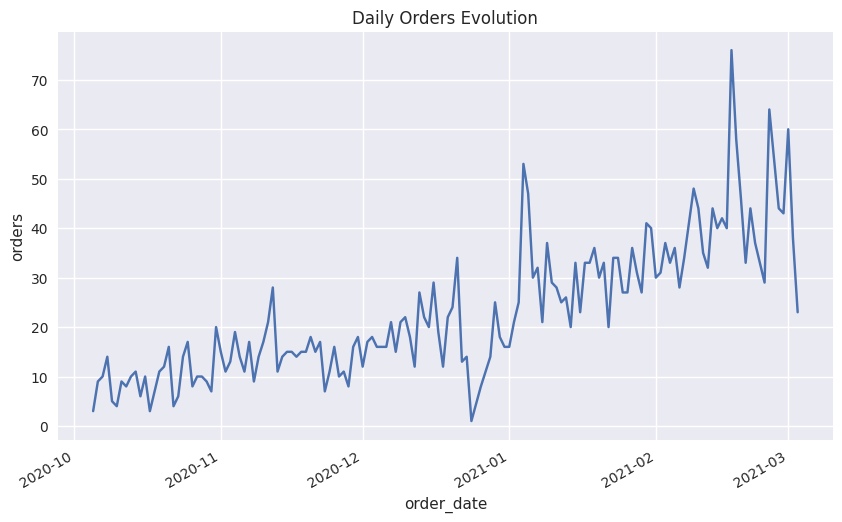

In [8]:
fig, ax = plt.subplots(figsize = (10,6))

df_raw.groupby('order_date')['order_id'].nunique().plot()
plt.title('Daily Orders Evolution')
plt.ylabel('orders')
plt.show()

### Time based split: Train, Validation, Split

In [9]:
daily_orders = df.groupby('order_date')['order_id'].nunique().cumsum()
total_orders = df.order_id.nunique()

train_cutoff = daily_orders[daily_orders <= 0.7 * total_orders].index[-1]
val_cutoff = daily_orders[daily_orders <= 0.9 * total_orders].index[-1]

train = df[df['order_date'] <= train_cutoff]
val = df[(df['order_date'] > train_cutoff) & (df['order_date']<= val_cutoff)]
test = df[df['order_date'] > val_cutoff]

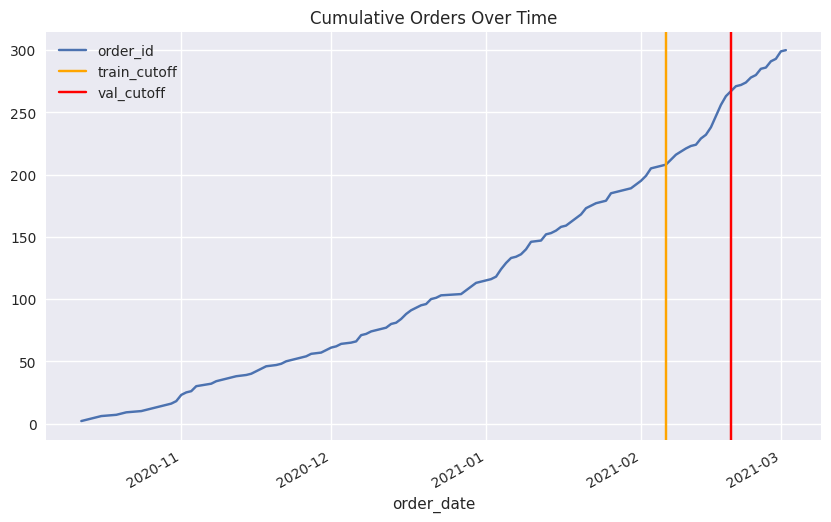

In [10]:
fig, ax = plt.subplots(figsize = (10,6))

daily_orders.plot()
ax.axvline(train_cutoff, color = 'orange', label = 'train_cutoff')
ax.axvline(val_cutoff, color = 'red', label = 'val_cutoff')
ax.legend()
plt.title('Cumulative Orders Over Time')
plt.show()

### Split Features and Target

In [11]:
target = 'outcome'

X_train = train.drop(columns = target)
y_train = train[target]

X_val = val.drop(columns = target)
y_val = val[target]

X_test = test.drop(columns = target)
y_test = test[target]

### Variable selection 

In [12]:
ids = ['order_id', 'user_id', 'variant_id', 'created_at','order_date']
bin = ['ordered_before','abandoned_before', 'active_snoozed', 'set_as_regular']
num = ['user_order_seq','normalised_price','discount_pct','global_popularity',
       'count_adults', 'count_children', 'count_babies', 'count_pets', 
       'people_ex_baby', 'days_since_purchase_variant_id', 
       'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 
       'days_since_purchase_product_type', 'avg_days_to_buy_product_type',
       'std_days_to_buy_product_type']
cat = ['product_type', 'vendor']
target = ['outcome']

Categorical variables (product_type and vendor) were excluded from the model, as their inclusion via encoding did not yield 
meaningful improvements in predictive performance while significantly increasing 
training time.

### Baseline

We will use the Ridge linear model used in the last module as the baseline model

In [13]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), num + bin),
    ]
)
# Ridge

best_ridge = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(penalty='l2', solver = 'liblinear', C=0.0001))
      ]
   )
best_ridge.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['user_order_seq',
                                                   'normalised_price',
                                                   'discount_pct',
                                                   'global_popularity',
                                                   'count_adults',
                                                   'count_children',
                                                   'count_babies', 'count_pets',
                                                   'people_ex_baby',
                                                   'days_since_purchase_variant_id',
                                                   'avg_days_to_buy_variant_id',
                                                   'std_days_to_buy_variant_id',
                                                   'days_since_purchase_product_type',
                                                   'avg_days_to_buy_product_type',
                                                   'std_days_to_buy_product_type',
                                                   'ordered_before',
                                                   'abandoned_before',
                                                   'active_snoozed',
                                                   'set_as_regular'])])),
                ('model', LogisticRegression(C=0.0001, solver='liblinear'))])

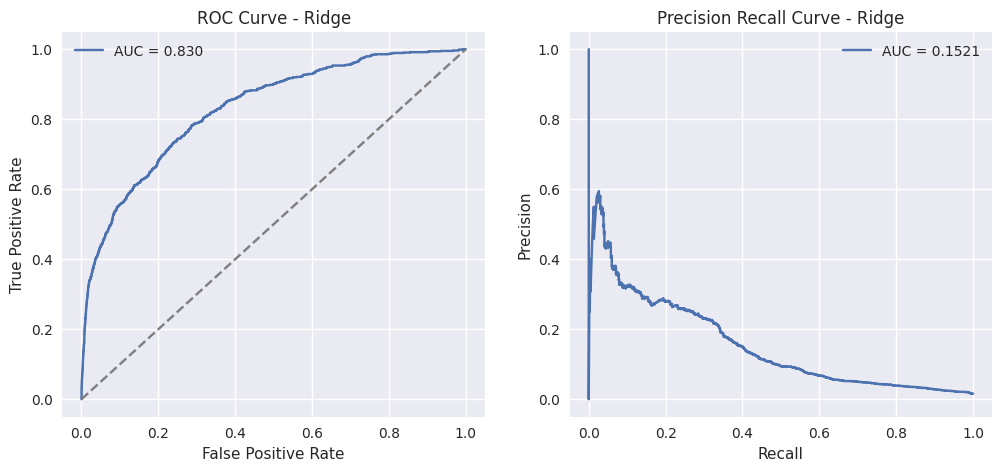

ROC-AUC: 0.8302
PR-AUC:  0.1521


In [14]:
# Linear Model: Ridge
probs_ridge = best_ridge.predict_proba(X_val)[:,1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, probs_ridge)
roc_auc = auc(fpr, tpr)

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_val, probs_ridge)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Ridge')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

ax[1].plot(recall, precision, label=f'AUC = {pr_auc:.4f}')
ax[1].set_title('Precision Recall Curve - Ridge')
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

### Non Linear Models

### Decision Tree

In [15]:
features = bin + num  

depths = [2, 3, 5, 8, 10, None]  

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train[features], y_train)
    
    auc_train = roc_auc_score(y_train, model.predict_proba(X_train[features])[:,1])
    auc_val   = roc_auc_score(y_val,   model.predict_proba(X_val[features])[:,1])
    
    print(f"max_depth={str(depth):>4}  |  AUC train: {auc_train:.4f}  |  AUC val: {auc_val:.4f}")

max_depth=   2  |  AUC train: 0.6545  |  AUC val: 0.6476
max_depth=   3  |  AUC train: 0.6595  |  AUC val: 0.6572
max_depth=   5  |  AUC train: 0.8168  |  AUC val: 0.7926
max_depth=   8  |  AUC train: 0.8431  |  AUC val: 0.8127
max_depth=  10  |  AUC train: 0.8517  |  AUC val: 0.8060
max_depth=None  |  AUC train: 0.9998  |  AUC val: 0.5566


In [16]:
best_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
best_tree.fit(X_train[features], y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Decision Tree results show a clear overfitting pattern. max_depth=5 achieves the best validation AUC (0.8168) with minimal train-val gap (0.0.7926), indicating good generalisation. 

Beyond that, overfitting increases sharply — depth=None reaches train AUC=0.998 but collapses to val AUC=0.5666. 

We select max_depth=5 as the optimal hyperparameter.

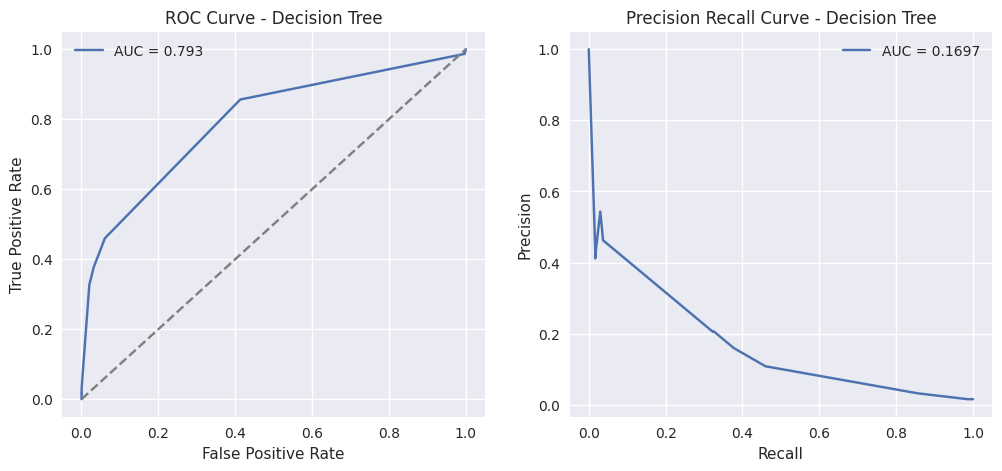

ROC-AUC: 0.7926
PR-AUC:  0.1697


In [17]:
# Decision Tree
probs_tree = best_tree.predict_proba(X_val[features])[:,1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, probs_tree)
roc_auc = auc(fpr, tpr)

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_val, probs_tree)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Decision Tree')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

ax[1].plot(recall, precision, label=f'AUC = {pr_auc:.4f}')
ax[1].set_title('Precision Recall Curve - Decision Tree')
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

### Random Forest

In [18]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8],
    'max_features': ['sqrt',0.5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train[features], y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
auc_train = roc_auc_score(y_train, best_rf.predict_proba(X_train[features])[:,1])
auc_val = roc_auc_score(y_val, best_rf.predict_proba(X_val[features])[:,1])
print(f"Train AUC: {auc_train:.4f}")
print(f"Val AUC:   {auc_val:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/home/alexm/curso-zrive/zrive-ds/.venv/lib/python3.11/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params: {'max_depth': 5, 'max_features': 0.5, 'n_estimators': 100}
Best CV AUC: 0.8390
Train AUC: 0.8399
Val AUC:   0.8321


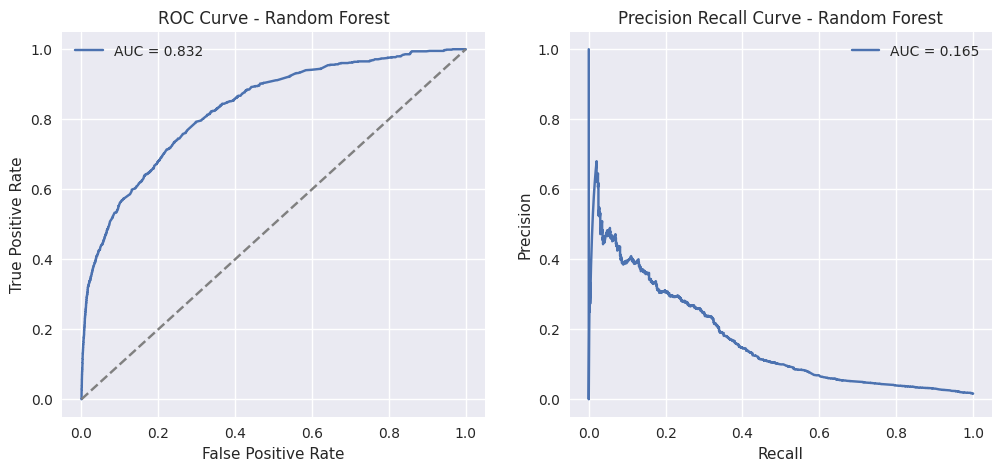

ROC-AUC: 0.8321
PR-AUC:  0.1651


In [19]:
# Random Forest
probs_rf = best_rf.predict_proba(X_val[features])[:,1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, probs_rf)
roc_auc = auc(fpr, tpr)

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_val, probs_rf)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Random Forest')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

ax[1].plot(recall, precision, label=f'AUC = {pr_auc:.3f}')
ax[1].set_title('Precision Recall Curve - Random Forest')
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

The best Random Forest configuration (max_depth=5, max_features=0.5, n_estimators=100) achieves a PR AUC of 0.165, slightly below the Decision Tree (0.170) but with a stronger ROC AUC of 0.832. 

The close train and validation AUC (0.840 vs 0.832) suggests the model is not overfitting.

In [20]:
importances = pd.Series(
    best_rf.feature_importances_, 
    index=features
).sort_values(ascending=False)

print(importances)

abandoned_before                    0.389292
ordered_before                      0.249104
global_popularity                   0.126737
days_since_purchase_variant_id      0.067913
set_as_regular                      0.040570
avg_days_to_buy_product_type        0.030128
avg_days_to_buy_variant_id          0.016790
std_days_to_buy_product_type        0.015931
user_order_seq                      0.013844
days_since_purchase_product_type    0.013221
discount_pct                        0.011167
normalised_price                    0.009833
std_days_to_buy_variant_id          0.009295
active_snoozed                      0.003834
count_pets                          0.000933
people_ex_baby                      0.000725
count_children                      0.000534
count_adults                        0.000152
count_babies                        0.000000
dtype: float64


Random Forest confirms the same top 3 features as the linear models, though abandoned_before becomes the strongest predictor (0.389) overtaking ordered_before. 

The ensemble additionally extracts signal from days_since_purchase_variant_id and set_as_regular, which were near-zero in Ridge and Lasso. Household composition features contribute negligibly across all models.

### XGBoost

In [21]:
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train[features], y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best CV AUC: {random_search.best_score_:.4f}")

best_xgb = random_search.best_estimator_
auc_val = roc_auc_score(y_val, best_xgb.predict_proba(X_val[features])[:,1])
print(f"Val AUC: {auc_val:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV AUC: 0.8516
Val AUC: 0.8351


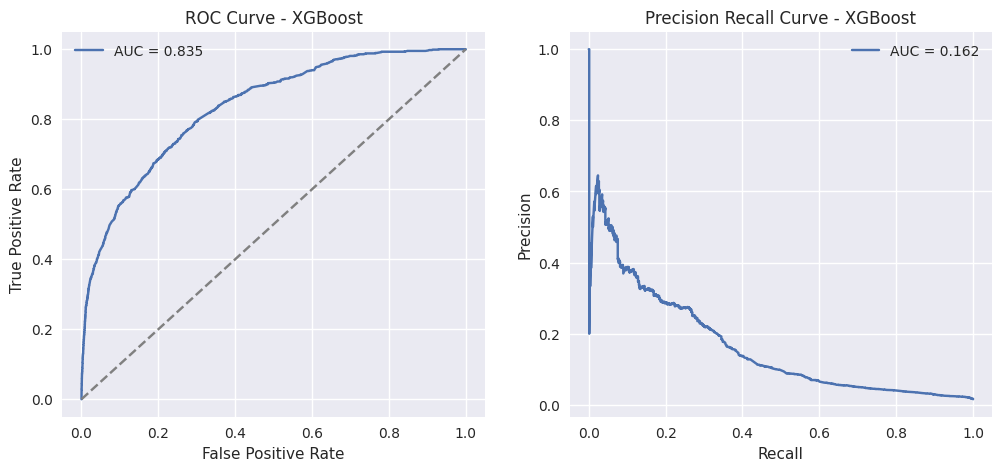

ROC-AUC: 0.8351
PR-AUC:  0.1625


In [22]:
probs_xgb = best_xgb.predict_proba(X_val[features])[:,1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, probs_xgb)
roc_auc = auc(fpr, tpr)

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_val, probs_xgb)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - XGBoost')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

ax[1].plot(recall, precision, label=f'AUC = {pr_auc:.3f}')
ax[1].set_title('Precision Recall Curve - XGBoost')
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

The best XGBoost configuration (max_depth=4, learning_rate=0.01, n_estimators=100, subsample=0.8, colsample_bytree=0.8) achieves the highest ROC AUC across all models (0.835), though its PR AUC of 0.163 remains below the Decision Tree (0.170). 

The shallow depth and low learning rate suggest the model benefits from conservative gradient updates, consistent with the small sample size.

In [23]:
importances_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importances_xgb)

ordered_before                      0.418610
abandoned_before                    0.160031
global_popularity                   0.117145
days_since_purchase_variant_id      0.052150
set_as_regular                      0.051291
active_snoozed                      0.031922
avg_days_to_buy_product_type        0.029751
user_order_seq                      0.021676
avg_days_to_buy_variant_id          0.021351
normalised_price                    0.019824
count_adults                        0.016333
std_days_to_buy_product_type        0.012327
days_since_purchase_product_type    0.011614
people_ex_baby                      0.011092
count_children                      0.007890
std_days_to_buy_variant_id          0.005775
discount_pct                        0.005633
count_pets                          0.005585
count_babies                        0.000000
dtype: float32


XGBoost restores ordered_before as the dominant feature (0.419), consistent with the linear models and contrasting with Random Forest where abandoned_before ranked first. 

The top 3 features remain the same across all models. Notably, active_snoozed gains more relevance in XGBoost (0.032) compared to Random Forest

### Models Comparison

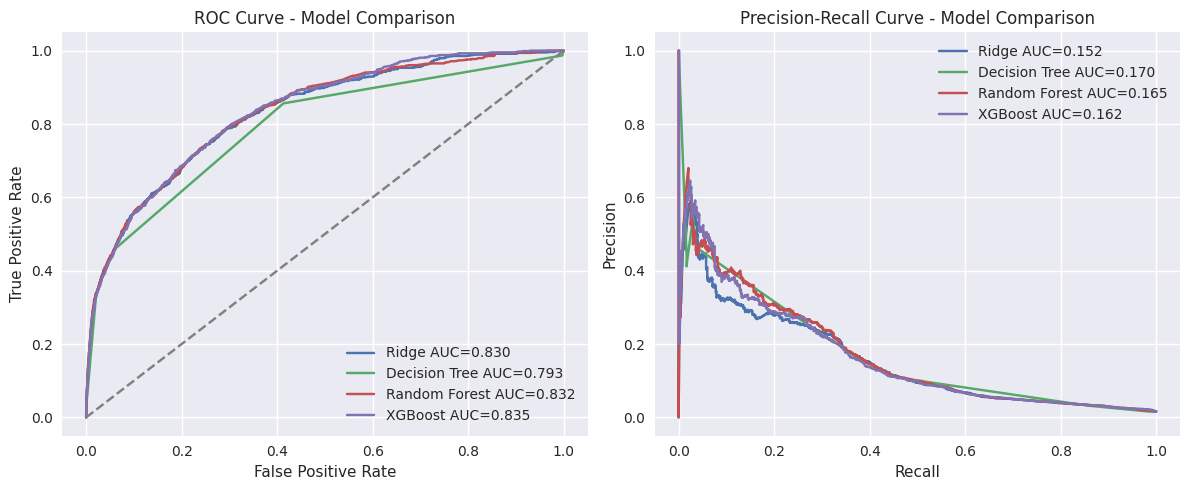

<Figure size 800x550 with 0 Axes>

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr_ridge, tpr_ridge, _ = roc_curve(y_val, probs_ridge)
fpr_tree, tpr_tree, _ = roc_curve(y_val, probs_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_val, probs_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, probs_xgb)

ax[0].plot(fpr_ridge, tpr_ridge, label=f'Ridge AUC={auc(fpr_ridge, tpr_ridge):.3f}')
ax[0].plot(fpr_tree, tpr_tree, label=f'Decision Tree AUC={auc(fpr_tree, tpr_tree):.3f}')
ax[0].plot(fpr_rf, tpr_rf, label=f'Random Forest AUC={auc(fpr_rf, tpr_rf):.3f}')
ax[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost AUC={auc(fpr_xgb, tpr_xgb):.3f}')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Model Comparison')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

# Precision-Recall Curve
prec_ridge, rec_ridge, _ = precision_recall_curve(y_val, probs_ridge)
prec_tree, rec_tree, _ = precision_recall_curve(y_val, probs_tree)
prec_rf, rec_rf, _ = precision_recall_curve(y_val, probs_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, probs_xgb)

ax[1].plot(rec_ridge, prec_ridge, label=f'Ridge AUC={auc(rec_ridge, prec_ridge):.3f}')
ax[1].plot(rec_tree, prec_tree, label=f'Decision Tree AUC={auc(rec_tree, prec_tree):.3f}')
ax[1].plot(rec_rf, prec_rf, label=f'Random Forest AUC={auc(rec_rf, prec_rf):.3f}')
ax[1].plot(rec_xgb, prec_xgb, label=f'XGBoost AUC={auc(rec_xgb, prec_xgb):.3f}')
ax[1].set_title('Precision-Recall Curve - Model Comparison')
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()

plt.tight_layout()
plt.show()
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()

plt.tight_layout()
plt.show()

### Conclusions

All models were trained on a sample of 300 orders and evaluated using PR AUC as 
the primary metric, given the class imbalance in the dataset.

As shown in the ROC curve, Ridge, Random Forest and XGBoost perform similarly in 
terms of overall discrimination, with the Decision Tree lagging behind. 

The PR curve shows narrow differences across all models (0.152–0.170), and the ranking should be 
interpreted with caution given the small sample size — with 300 orders, these gaps 
are unlikely to be statistically significant and may not hold on the full dataset.

Training on the full 2603 orders would provide more reliable estimates and would 
likely surface the expected performance advantage of ensemble methods over a single 
Decision Tree.

The top 3 features — ordered_before, abandoned_before, and global_popularity — are 
consistent across all models, confirming that past user interaction with a product 
is the strongest signal for purchase intent, which aligns directly with the goal of 
targeting push notifications to users who have already shown interest.

XGBoost is carried forward as the best model, as it achieves 
the best ROC AUC (0.835) and its marginal PR AUC gap with the Decision Tree is 
likely a sample size artefact rather than a genuine performance difference.

### Model evaluation on Test Set

In [25]:
probs_rf_test = best_xgb.predict_proba(X_test[features])[:,1]


roc_auc_test = roc_auc_score(y_test, probs_rf_test)
pr_auc_test = auc(*precision_recall_curve(y_test, probs_rf_test)[1::-1])

print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print(f"Test PR-AUC:  {pr_auc_test:.4f}")

Test ROC-AUC: 0.8341
Test PR-AUC:  0.1602


XGBoost in the test set is consistent with the validation results, confirming the model generalises well and is not overfitting to the training sample.

### Model Calibration

In [27]:
from sklearn.calibration import CalibratedClassifierCV


calibrated_xgb = CalibratedClassifierCV(best_xgb, cv='prefit', method='sigmoid')
calibrated_xgb.fit(X_val[features], y_val)


probs_calibrated_val = calibrated_xgb.predict_proba(X_val[features])[:,1]
print("--- Validation ---")
print(f"ROC-AUC: {roc_auc_score(y_val, probs_calibrated_val):.4f}")
print(f"PR-AUC:  {auc(*precision_recall_curve(y_val, probs_calibrated_val)[1::-1]):.4f}")

--- Validation ---
ROC-AUC: 0.8351
PR-AUC:  0.1625


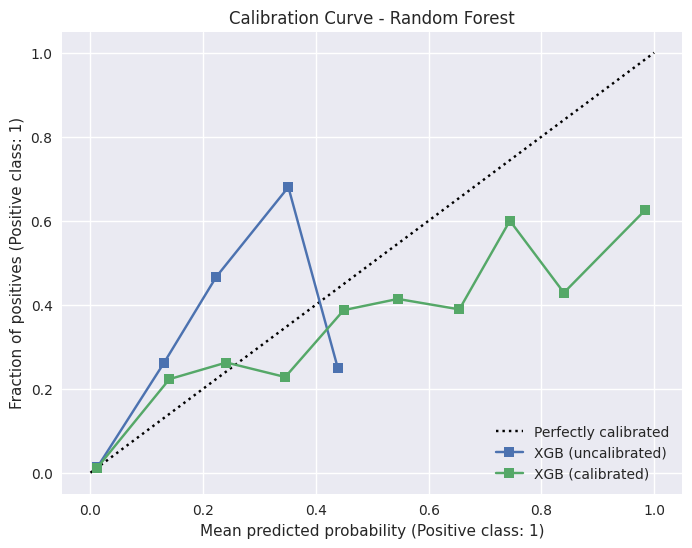

In [28]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_val, probs_xgb, 
    n_bins=10, 
    ax=ax, 
    label='XGB (uncalibrated)'
)

CalibrationDisplay.from_predictions(
    y_val, probs_calibrated_val, 
    n_bins=10, 
    ax=ax, 
    label='XGB (calibrated)'
)

ax.set_title('Calibration Curve - Random Forest')
plt.show()

The calibration curve shows that the uncalibrated XGBoost model is poorly calibrated, with erratic predicted probabilities that deviate significantly from the ideal diagonal. 

After calibration, the model follows the diagonal more closely, particularly in the lower probability range, though it still overestimates in the mid-range (0.4–0.8). 

Good calibration is important in this context as the model's output will be used to rank and prioritise which customers to target with push notifications.

Results would be more reliable with the full 2600-order dataset.